In [62]:
%load_ext autoreload
%reload_ext autoreload

from helper import fitting, models, plot
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd
import sys
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Initialization

In [63]:
def get_dir():
    if sys.platform == "win32": # windows
        dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\vis_test (caprese) results"
    elif sys.platform == "darwin": # mac
        dir = "/Volumes/Coolens_Research/Isaac/Experiments/vis_test (caprese) results"
    else:
        raise ValueError("Unable to get directory.")

    return dir

def import_dat(boundary = True):
    dir = get_dir()
    keys = ["depth_df", "time_df", "conc_df"]
    files = ["vis_x.csv", "vis_time.csv", "vis_conc_xt.csv"]
    if boundary:
        folder = os.path.join(dir, "boundary_true")
    else:
        folder = os.path.join(dir, "boundary_false")

    folders = {k: os.path.join(folder, v) for k, v in zip(keys, files)}
    out = {k: pd.read_csv(folders[k], dtype = float) for k in keys}

    return out

In [107]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[:30]
depth = depth - np.nanmin(depth)
conc = conc[:, :30]

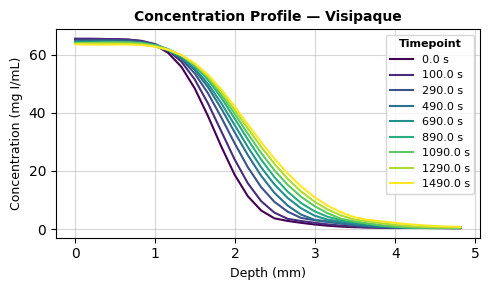

In [65]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

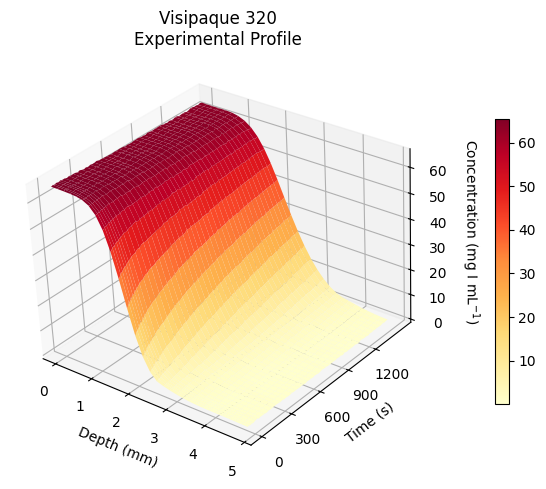

In [66]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# Fitting

## Global D, Cs, x0
With no boundary, so only for fits with x0

In [67]:
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        if fit_x0:
            x0_mode = "global"
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
        else:
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
print(f"# of configs: {len(configs)}")

# of configs: 2


In [68]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [69]:
c_null = 25

t_front = np.sqrt(time)
x_front = []

for i in range(conc.shape[0]):
    profile = conc[i, :]

    # find where concentration crosses c_null
    idx = np.where(np.diff(np.sign(profile - c_null)))[0]

    if len(idx) > 0:
        j = idx[0]

        # two surrounding pixels
        c1, c2 = profile[j], profile[j+1]
        x1, x2 = depth[j], depth[j+1]

        # linear interpolation
        x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

        x_front.append(x)

    else:
        x_front.append(np.nan)

In [70]:
from scipy import stats
from scipy.special import erfcinv

n = len(x_front)

slope, intercept, r_value, p_value, std_err = stats.linregress(t_front, x_front)

d_front = (slope / (2 * erfcinv(c_null / cs_exp)))**2

df = n - 2
t_val = stats.t.ppf(0.975, df)
margin_of_err = t_val * std_err
slope_lower = slope - margin_of_err
slope_upper = slope + margin_of_err

lb = (slope_lower / (2 * erfcinv(c_null / cs_exp)))**2
ub = (slope_upper / (2 * erfcinv(c_null / cs_exp)))**2

print(f"D: {d_front:.3e} mm2/s [{lb:.3e}, {ub:.3e}] (r2 = {r_value**2:.3f})")
print(f"Intercept: {intercept}")

D: 1.781e-04 mm2/s [1.723e-04, 1.840e-04] (r2 = 0.995)
Intercept: 1.8161586185832372


In [111]:
depth[12]

np.float64(1.992)

In [112]:
sim_conc = np.empty((len(time), len(depth)))
first_row = conc[:, 12]
cs_experimental = np.nanmean(first_row)
d_front = d_front

semi_inf = models.semi_infinite

conc_sim = np.zeros_like(conc)

for i, ti in enumerate(time):
    if ti == 0:
        conc_sim[i, :] = semi_inf(depth, intercept, d_front, cs_experimental, 0.001)
    else:
        conc_sim[i, :] = semi_inf(depth, intercept, d_front, cs_experimental, ti)

n = conc.size
p = 1

residuals = conc - conc_sim

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((conc - np.mean(conc)) ** 2)

rse = np.sqrt(np.sum(residuals) ** 2 / (n - p))
r2 = 1 - ss_res / ss_tot

print(f"RSE = {rse} mg/mL")
print(f"r2 = {r2}")

RSE = 113.61403408495471 mg/mL
r2 = 0.9491212454990435


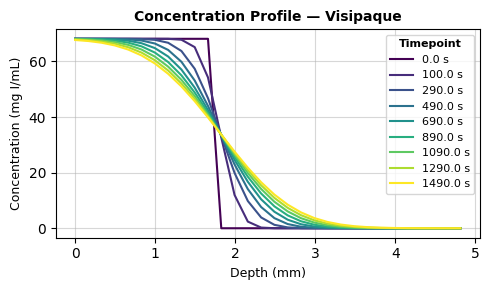

In [113]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc_sim[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)


ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

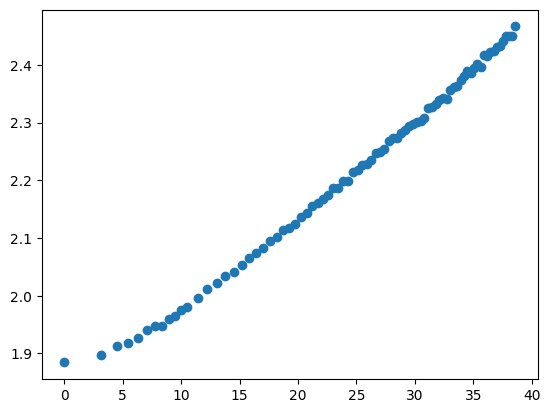

In [72]:
fig, ax = plt.subplots()
ax.scatter(t_front, x_front, marker = "o")

In [73]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)

    if cfg.fit_x0:
        x0_summary = np.nanmedian(r.x0_per_t) if cfg.x0_mode == "per-timepoint" else r.x0_global
    else:
        x0_summary = np.nan

    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "x0_mode": cfg.x0_mode,
        "D": d_summary,
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "x0": x0_summary,
        "R2": r.r2_global,
        "RSE_mean": np.nanmean(r.rse_per_t) if r.rse_per_t is not None else np.nan,
        "Global RSE": r.rse_global,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df_bound = pd.DataFrame(rows)
summary_df_bound["delta_aic"] = summary_df_bound["AIC"] - summary_df_bound["AIC"].min()
summary_df_bound["delta_bic"] = summary_df_bound["BIC"] - summary_df_bound["BIC"].min()
summary_df_bound.sort_values("delta_aic")

,model,fit_x0,d_mode,cs_mode,x0_mode,D,Cs,x0,R2,RSE_mean,Global RSE,AIC,BIC,n_params,delta_aic,delta_bic
0,semi-infinite,True,global,global,global,0.000288,32.888158,2.008024,0.977760,3.490283,4.054208,6721.823877,6739.173549,3,0.000000,0.000000
1,semi-infinite,True,global,fixed,global,0.002982,64.449782,0.628168,0.797592,11.343696,12.228271,12020.001692,12031.568140,2,5298.177815,5292.394591


# With Manual Boundary

In [74]:
dat = import_dat(boundary = True)

conc, depth, time = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth = depth.flatten()
time = time.flatten()

depth = depth[:25]
conc = conc[:, :25]
time = time

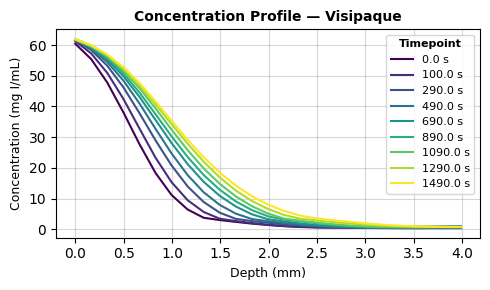

In [75]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

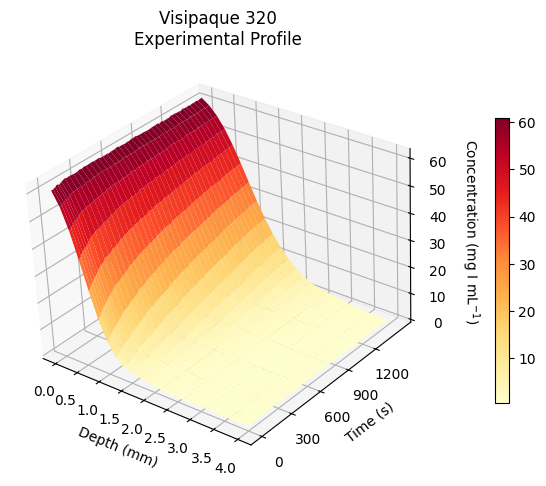

In [76]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

In [77]:
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [False]:
    for cs_mode in ["global", "fixed"]:
        if fit_x0:
            x0_mode = "global"
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
        else:
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
print(f"# of configs: {len(configs)}")

# of configs: 2


In [78]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [79]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)

    if cfg.fit_x0:
        x0_summary = np.nanmedian(r.x0_per_t) if cfg.x0_mode == "per-timepoint" else r.x0_global
    else:
        x0_summary = np.nan

    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "x0_mode": cfg.x0_mode,
        "D": d_summary,
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "x0": x0_summary,
        "R2": r.r2_global,
        "RSE_mean": np.nanmean(r.rse_per_t) if r.rse_per_t is not None else np.nan,
        "Global RSE": r.rse_global,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df = pd.DataFrame(rows)
summary_df["delta_aic"] = summary_df["AIC"] - summary_df["AIC"].min()
summary_df["delta_bic"] = summary_df["BIC"] - summary_df["BIC"].min()
summary_df.sort_values("delta_aic")

,model,fit_x0,d_mode,cs_mode,x0_mode,D,Cs,x0,R2,RSE_mean,Global RSE,AIC,BIC,n_params,delta_aic,delta_bic
0,semi-infinite,False,global,global,global,0.001021,66.780652,NaN,0.915948,5.099061,5.999467,7168.681574,7179.883379,2,0.000000,0.00000
1,semi-infinite,False,global,fixed,global,0.001159,61.624955,NaN,0.909797,5.501264,6.213571,7307.942837,7313.543739,1,139.261262,133.66036


# Plotting vs experimental profile

## Free Boundary

In [80]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[12:30]
depth = depth - np.nanmin(depth)
conc = conc[:, 12:30]

In [81]:
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        if fit_x0:
            x0_mode = "global"
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
        else:
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
print(f"# of configs: {len(configs)}")

# of configs: 2


In [82]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [83]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)

    if cfg.fit_x0:
        x0_summary = np.nanmedian(r.x0_per_t) if cfg.x0_mode == "per-timepoint" else r.x0_global
    else:
        x0_summary = np.nan

    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "x0_mode": cfg.x0_mode,
        "D": d_summary,
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "x0": x0_summary,
        "R2": r.r2_global,
        "RSE_mean": np.nanmean(r.rse_per_t) if r.rse_per_t is not None else np.nan,
        "Global RSE": r.rse_global,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df_2 = pd.DataFrame(rows)
summary_df_2["delta_aic"] = summary_df_2["AIC"] - summary_df_2["AIC"].min()
summary_df_2["delta_bic"] = summary_df_2["BIC"] - summary_df_2["BIC"].min()
summary_df_2.sort_values("delta_aic")

,model,fit_x0,d_mode,cs_mode,x0_mode,D,Cs,x0,R2,RSE_mean,Global RSE,AIC,BIC,n_params,delta_aic,delta_bic
0,semi-infinite,True,global,global,global,0.000342,35.095586,1.794592e-19,0.960695,1.766812,2.023470,2032.86057,2048.677765,3,0.00000,0.000000
1,semi-infinite,True,global,fixed,global,0.000360,34.079079,1.518753e-16,0.959800,1.823413,2.045653,2063.26390,2073.808697,2,30.40333,25.130932


## Filtering data

In [84]:
combined = pd.concat([summary_df, summary_df_bound], keys = ["False", "True"])
combined = combined.reset_index(level = 0).rename(columns = {"level_0": "boundary"})

combined = pd.concat([combined, summary_df_2], keys = ["0mm", "2mm"])
combined = combined.reset_index(level = 0).rename(columns = {"level_0": "depth_shift"})
combined = combined.reset_index(drop = True)

In [85]:
combined

,depth_shift,boundary,model,fit_x0,d_mode,cs_mode,x0_mode,D,Cs,x0,R2,RSE_mean,Global RSE,AIC,BIC,n_params,delta_aic,delta_bic
0,0mm,False,semi-infinite,False,global,global,global,0.001021,66.780652,NaN,0.915948,5.099061,5.999467,7168.681574,7179.883379,2,0.000000,0.000000
1,0mm,False,semi-infinite,False,global,fixed,global,0.001159,61.624955,NaN,0.909797,5.501264,6.213571,7307.942837,7313.543739,1,139.261262,133.660360
2,0mm,True,semi-infinite,True,global,global,global,0.000288,32.888158,2.008024e+00,0.977760,3.490283,4.054208,6721.823877,6739.173549,3,0.000000,0.000000
3,0mm,True,semi-infinite,True,global,fixed,global,0.002982,64.449782,6.281681e-01,0.797592,11.343696,12.228271,12020.001692,12031.568140,2,5298.177815,5292.394591
4,2mm,NaN,semi-infinite,True,global,global,global,0.000342,35.095586,1.794592e-19,0.960695,1.766812,2.023470,2032.860570,2048.677765,3,0.000000,0.000000
5,2mm,NaN,semi-infinite,True,global,fixed,global,0.000360,34.079079,1.518753e-16,0.959800,1.823413,2.045653,2063.263900,2073.808697,2,30.403330,25.130932
